In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as pltt
from matplotlib import cm
from matplotlib import rc
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors
import warnings
warnings.simplefilter('ignore')
import plotting_functions as pf

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option("display.float_format", "{:.0f}".format)

# Data load

In [2]:
df_opt = pd.read_csv(r'base_data\PhNH2_BnOH.csv', sep = '\t') #data exclusively on PhNH2 and BnOH reaction including optimization data
df_nitro = pd.read_csv(r'base_data\PhNO2_BnOH.csv', sep = '\t') #data exclusively on PhNO2 and BnOH reaction including optimization data
df_substr = pd.read_csv(r'base_data\substrates.csv', sep = '\t') #data on substrate scope. Covers both nitro and amines
df_meoh = pd.read_csv(r'base_data\MeOH.csv', sep = '\t') #data on alkylation usong MeOH

In [3]:
df_opt.shape, df_nitro.shape, df_substr.shape, df_meoh.shape

((3439, 22), (308, 21), (9201, 24), (308, 21))

In [4]:
df_substr.columns

Index(['doi', 'solvent', 'amine_type', 'pKa_amine', 'n_amine', 'alcohol_type',
       'pKa_alcohol', 'n_alcohol', 'base', 'base_amount', 'catalyst', 'metal',
       'ligand', 'atmosphere', 'metal_load', 'temp', 'time', 'yield', 'TON',
       'atm_type', 'year', 'base_amine_ratio', 'base_alcohol_ratio',
       'reag_ratio'],
      dtype='str')

In [5]:
df_opt.columns

Index(['doi', 'solvent', 'PhNH2', 'BnOH', 'alc2aniline_ratio', 'base',
       'base_amount', 'catalyst', 'metal', 'ligand', 'atmosphere', 'cat_load',
       'temp', 'time', 'yield', 'TON', 'comment', 'success', 'atm_type',
       'year', 'base_amine_ratio', 'base_alcohol_ratio'],
      dtype='str')

In [6]:
df_substr['amine_type'].value_counts()

amine_type
Aromatic        5234
Aliphatic       1323
Hetaromatic     1073
ArNO2            607
Sulfonamide      382
Ammonia          184
Amide            153
Alk2NH            56
HetAromatic       37
amide             34
NH4OAc            28
Sulfinamide       26
SulfonamideK      12
ArAlkNH           11
AlkNO2            11
Ph2NH              9
NH4BF4             9
HCOONH4            8
HetNO2             4
Name: count, dtype: int64

In [7]:
df_substr['alcohol_type'].value_counts()

alcohol_type
BnOH          5339
AlkCH2OH      1537
ArCH2OH        683
MeOH           662
Alk2CHOH       456
AlkArCHOH      260
Bn2OH          110
HetBnOH         74
AllOH           49
AlkEWGCHOH      11
FcOH            10
ArEWGCHOH        6
EWGCH2OH         4
Name: count, dtype: int64

# Borrowing hydrogen amination

In [8]:
#only BH reactions
nitro = ['ArNO2', 'AlkNO2', 'HetNO2']
df_substr_hb = df_substr[~df_substr['amine_type'].isin(nitro)]
df_substr_hb.shape

(8579, 24)

## Catalyst's activity and metals usage

In [9]:
cat_df = pd.concat([
    df_opt[['doi', 'catalyst', 'metal', 'ligand', 'yield', 'cat_load', 'TON', 'base', 'atm_type', 'year']],
    df_substr_hb[['doi', 'catalyst', 'metal', 'ligand', 'yield', 'metal_load', 'TON', 'base', 'atm_type', 'year']].rename(columns = {'metal_load': 'cat_load'})
])
cat_df.dropna(subset = 'TON', inplace = True)
cat_df.dropna(subset = 'metal', inplace = True)
cat_df = cat_df[cat_df['metal'].apply(lambda x: len(x.split(',')) == 1)].copy()
cat_df = cat_df[cat_df['cat_load'] > 0]
cat_df = cat_df[cat_df['TON'] > 5].copy()
cat_df.sort_values(by = 'TON', ascending = False, inplace = True)
cat_df.drop_duplicates(subset = ['catalyst', 'ligand', 'doi'], inplace = True)
cat_df.reset_index(drop = True, inplace = True)
print(f'We have {cat_df.shape[0]} different catalysts')

We have 922 different catalysts


In [10]:
def get_activity(ton):
    if ton >=500:
        return 'active'
    elif ton>=100:
        return 'medium'
    else:
        return 'low'

cat_df['activity'] = cat_df['TON'].apply(get_activity)

In [11]:
cat_df.head()

,doi,catalyst,metal,ligand,yield,cat_load,TON,base,atm_type,year,activity
0,10.1016/j.tet.2017.03.001,Pd2((AcO)pirazoleAr3)2,Pd,"P(2-Fu)3 (0,4 mol%), 4A MS",89,0,44500,LiOH,inert,2017,active
1,10.1002/adsc.201701117,"Ru(1,10-phenanthroline)Py(PPh3)2(PF6)",Ru,no,43,0,42840,tBuOK,inert,2017,active
2,10.1021/acs.inorgchem.9b03049,RuNHC,Ru,no,33,0,33000,tBuOK,inert,2020,active
3,10.1021/acs.organomet.0c00233,NiNNN,Ni,no,68,0,32640,tBuONa,inert,2020,active
4,10.1016/j.tet.2016.11.029,"Pt-Sn/g-Al2O3 (0,05 mol% Pt)",Pt,no,95,0,18627,no base,inert,2016,active


In [12]:
#catalysts before 2022
cat_df.loc[cat_df['year']<2022]['activity'].value_counts()

activity
low       443
medium    120
active     36
Name: count, dtype: int64

In [13]:
# whole data on catalysts
cat_df['activity'].value_counts()

activity
low       696
medium    168
active     58
Name: count, dtype: int64

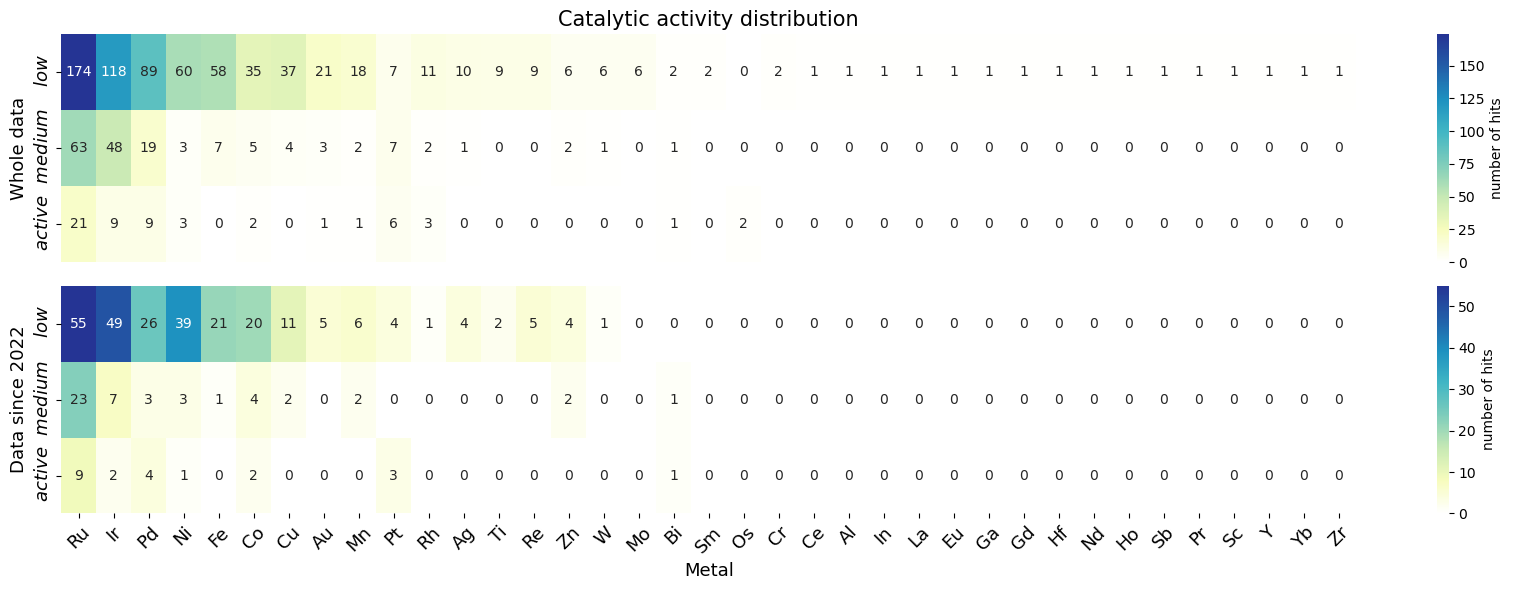

In [14]:
pf.plot_diff_graph(    
    cat_df, 
    'activity', 
    'metal',
    filter_val = 0,
    figsize = (17, 6),
    xlabel = 'Metal',
    title = 'Catalytic activity distribution'   
)

In [15]:
cat_df = pd.concat([
    df_opt[['doi', 'catalyst', 'metal', 'ligand', 'yield', 'cat_load', 'TON', 'base', 'atm_type', 'year']],
    df_substr_hb[['doi', 'catalyst', 'metal', 'ligand', 'yield', 'metal_load', 'TON', 'base', 'atm_type', 'year']].rename(columns = {'metal_load': 'cat_load'})
])
cat_df['success'] = cat_df['yield'] > 65
metals_full = cat_df[cat_df['success']]['metal'].value_counts()
metals_new = cat_df.loc[(cat_df['success']) & (cat_df['year']>=2022)]['metal'].value_counts()
df_metals = pd.concat([metals_full, metals_new ], axis = 1)
df_metals.columns = ['full data', 'data since 2022']
df_metals[df_metals.index.isin([x for x in df_metals.index if len(x.split(','))==1])]

,full data,data since 2022
metal,,
Ru,1914,504
Ir,1536,358
Pd,571,103
Ni,556,222
Co,497,317
Cu,436,207
Fe,384,62
Mn,322,79
Rh,148,1


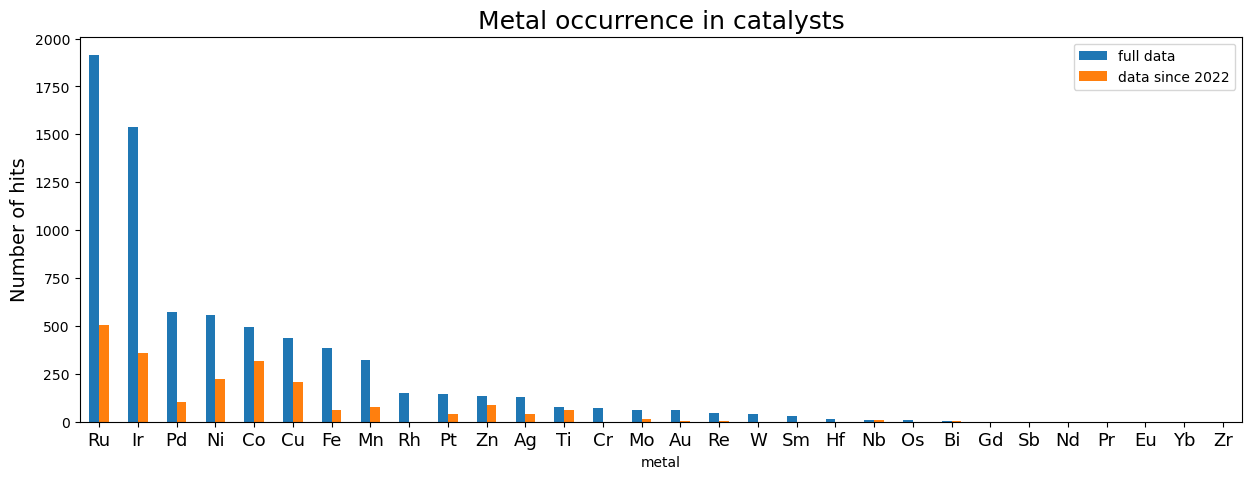

In [16]:
ax=df_metals[df_metals.index.isin([x for x in df_metals.index if len(x.split(','))==1])].plot(kind='bar', figsize=(15,5))

ax.set_ylabel('Number of hits', fontsize = 14)
ax.set_title('Metal occurrence in catalysts', fontsize = 18)
plt.xticks(fontsize=13, rotation='horizontal');

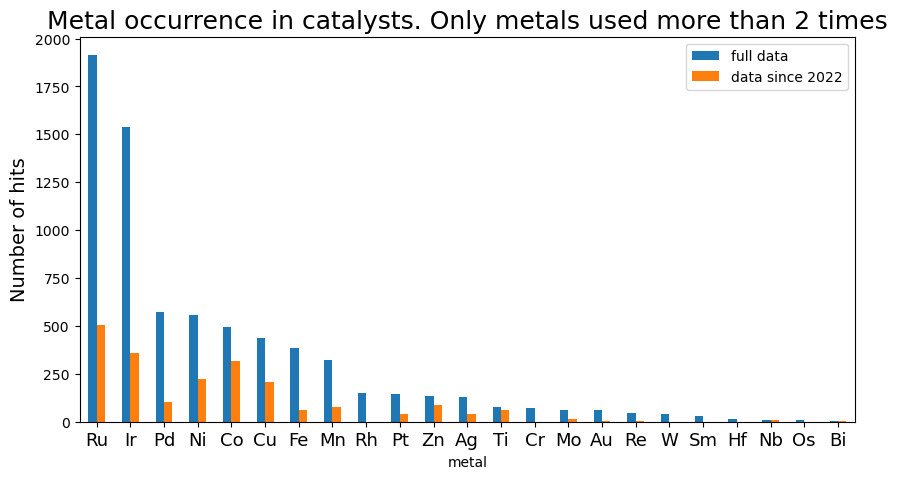

In [17]:
ax=df_metals.loc[
    (df_metals.index.isin([x for x in df_metals.index if len(x.split(','))==1])) &
    (df_metals['full data'] > 2)
    ].plot(kind='bar', figsize=(10,5))

ax.set_ylabel('Number of hits', fontsize = 14)
ax.set_title('Metal occurrence in catalysts. Only metals used more than 2 times', fontsize = 18)
plt.xticks(fontsize=13, rotation='horizontal');

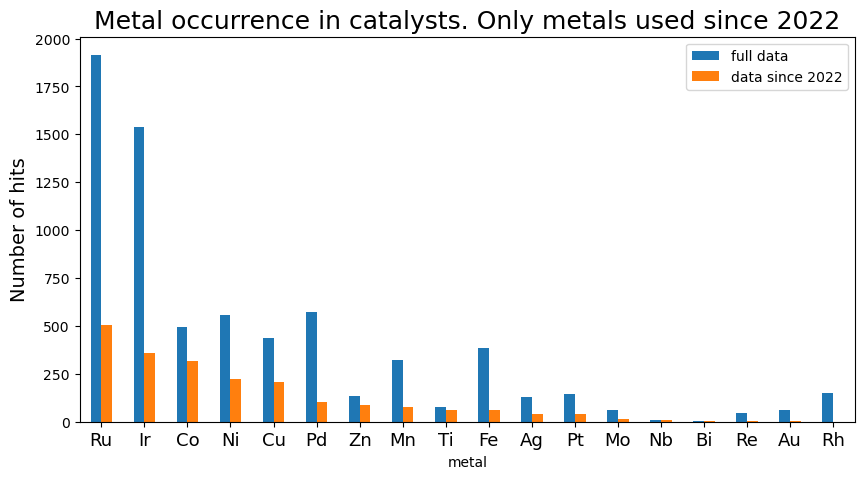

In [18]:
ax=df_metals.loc[
    (df_metals.index.isin([x for x in df_metals.index if len(x.split(','))==1])) &
    (df_metals['data since 2022'] >= 1)    
    ].sort_values(by = 'data since 2022', ascending = False).plot(kind='bar', figsize=(10,5))

ax.set_ylabel('Number of hits', fontsize = 14)
ax.set_title('Metal occurrence in catalysts. Only metals used since 2022', fontsize = 18)
plt.xticks(fontsize=13, rotation='horizontal');

## Comparison of metal-catalyzed and transition metal-free reaction

In [71]:
benchmark_yield = 65 # this is an yield of the reaction to consider it successful. In this section it is 50.
df_substr_hb_succ = df_substr_hb[df_substr_hb['yield'] > benchmark_yield]
df_opt_succ = df_opt[df_opt['yield'] > benchmark_yield] 

In [72]:
importlib.reload(pf)

<module 'plotting_functions' from 'C:\\Users\\oiafa\\python_work\\HB_analytics\\borrowing_hydrogen_amination_with_amines_and_nitro\\plotting_functions.py'>

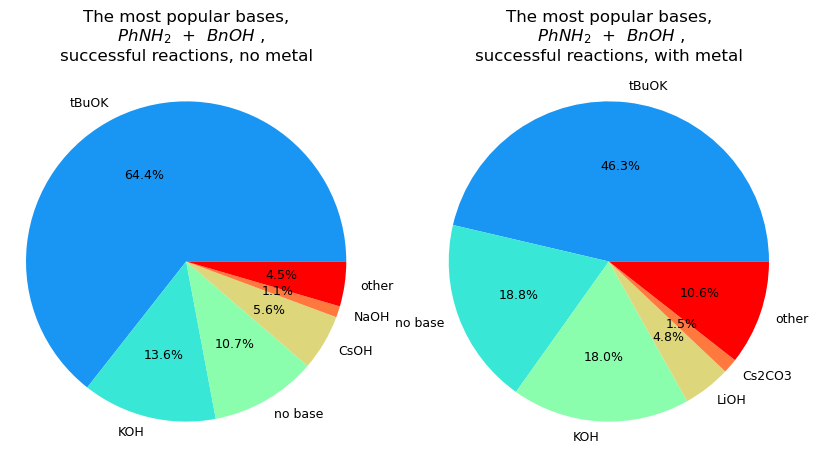

In [73]:
pf.compare_pie(df_opt_succ, 'base', [f'The most popular bases,\n {pf.to_chem('PhNH2')} + {pf.to_chem('BnOH')},\nsuccessful reactions, no metal',
                                 f'The most popular bases,\n{pf.to_chem('PhNH2')} + {pf.to_chem('BnOH')},\nsuccessful reactions, with metal'])

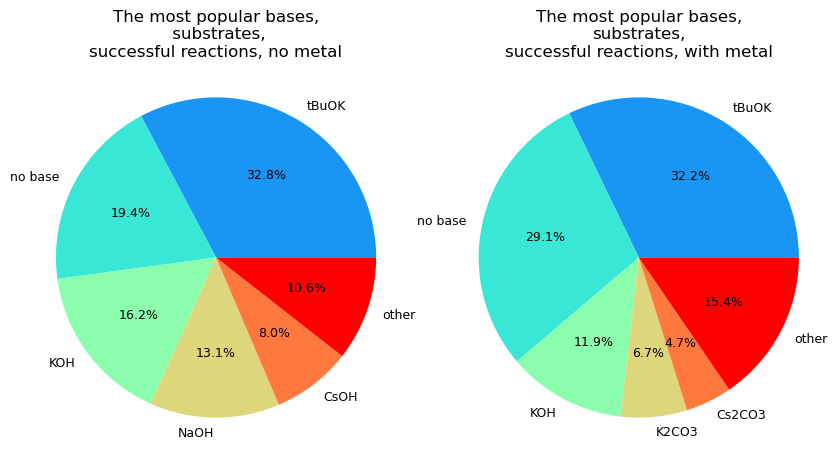

In [74]:
pf.compare_pie(df_substr_hb_succ, 'base', [f'The most popular bases,\n substrates,\nsuccessful reactions, no metal',
                                 f'The most popular bases,\nsubstrates,\nsuccessful reactions, with metal'])

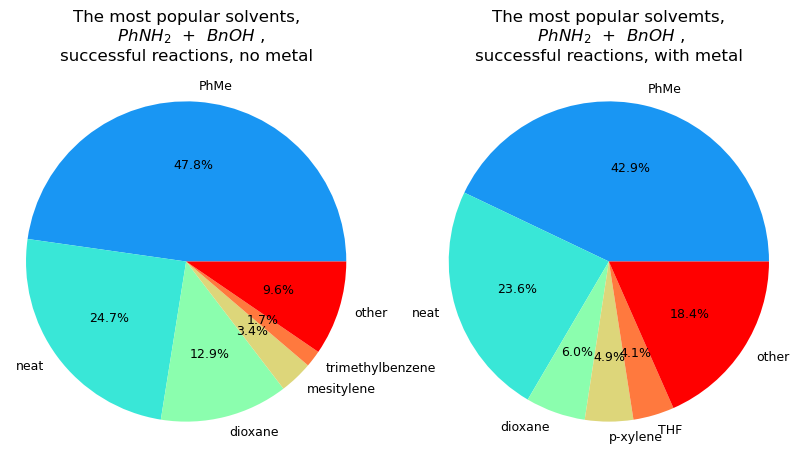

In [75]:
pf.compare_pie(df_opt_succ, 'solvent', [f'The most popular solvents,\n {pf.to_chem('PhNH2')} + {pf.to_chem('BnOH')},\nsuccessful reactions, no metal',
                                 f'The most popular solvemts,\n{pf.to_chem('PhNH2')} + {pf.to_chem('BnOH')},\nsuccessful reactions, with metal'],
              limit_items = 5)

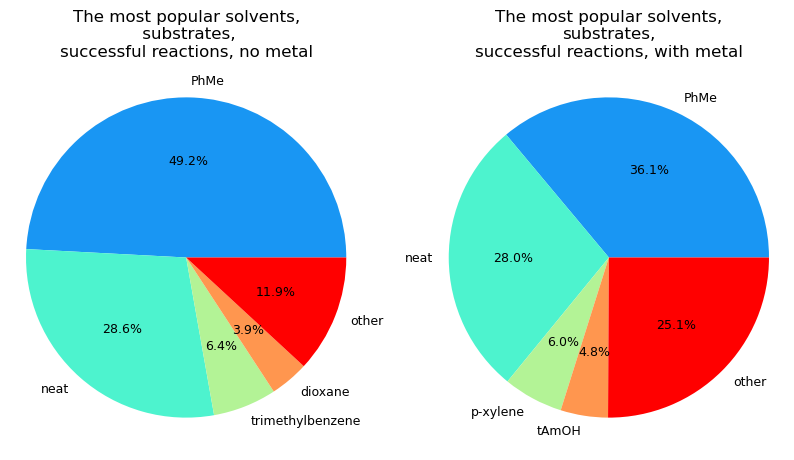

In [76]:
pf.compare_pie(df_substr_hb_succ, 'solvent', [f'The most popular solvents,\n substrates,\nsuccessful reactions, no metal',
                                 f'The most popular solvents,\nsubstrates,\nsuccessful reactions, with metal'], 
              limit_items = 4)

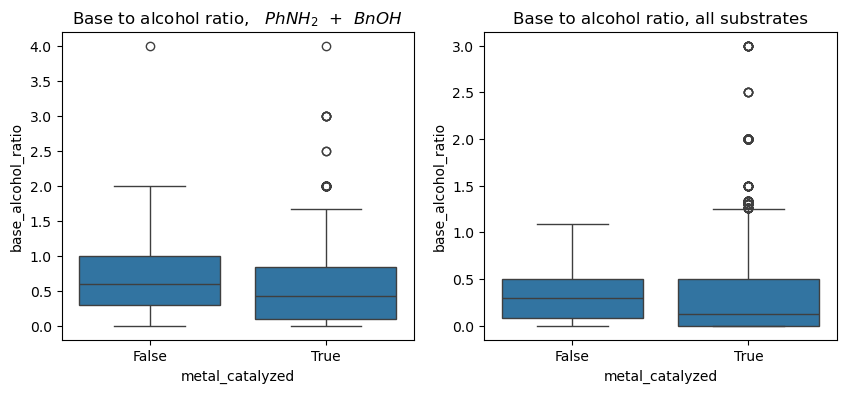

In [80]:
plt.figure(figsize=(10,4))
ax = plt.subplot(1, 2, 1) 
df_opt_succ['metal_catalyzed'] = ~df_opt_succ['metal'].isna()
sns.boxplot(data=df_opt_succ, y="base_alcohol_ratio", x="metal_catalyzed")
ax.set_title(f'Base to alcohol ratio,  {pf.to_chem('PhNH2')} + {pf.to_chem('BnOH')}', fontsize = 12);

ax = plt.subplot(1, 2, 2) 
df_substr_hb_succ['metal_catalyzed'] = ~df_substr_hb_succ['metal'].isna()
sns.boxplot(data=df_substr_hb_succ, y="base_alcohol_ratio", x="metal_catalyzed")
          
ax.set_title('Base to alcohol ratio, all substrates', fontsize = 12);
plt.show()
df_substr_hb_succ.drop('metal_catalyzed', axis=1, inplace = True)
df_opt_succ.drop('metal_catalyzed', axis=1, inplace = True)


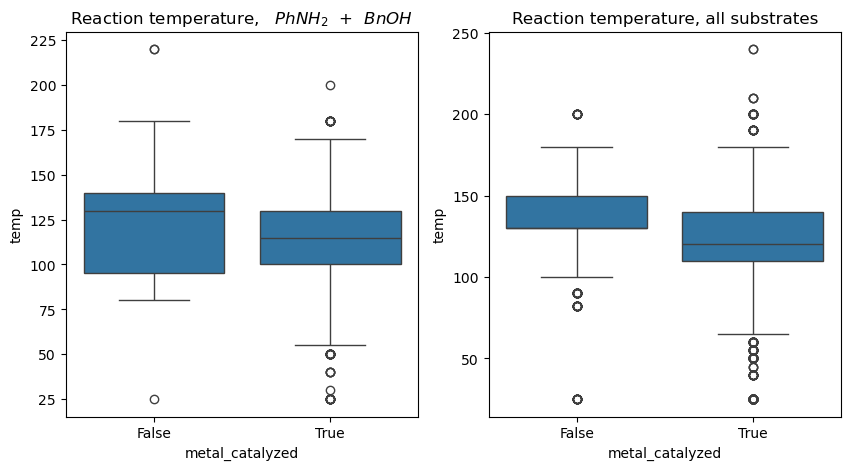

In [81]:
plt.figure(figsize=(10,5))
ax = plt.subplot(1, 2, 1) 
df_opt_succ['metal_catalyzed'] = ~df_opt_succ['metal'].isna()
sns.boxplot(data=df_opt_succ, y="temp", x="metal_catalyzed")
ax.set_title(f'Reaction temperature,  {pf.to_chem('PhNH2')} + {pf.to_chem('BnOH')}', fontsize = 12);

ax = plt.subplot(1, 2, 2) 
df_substr_hb_succ['metal_catalyzed'] = ~df_substr_hb_succ['metal'].isna()
sns.boxplot(data=df_substr_hb_succ, y="temp", x="metal_catalyzed")
          
ax.set_title('Reaction temperature, all substrates', fontsize = 12);
plt.show()
df_substr_hb_succ.drop('metal_catalyzed', axis=1, inplace = True)
df_opt_succ.drop('metal_catalyzed', axis=1, inplace = True)

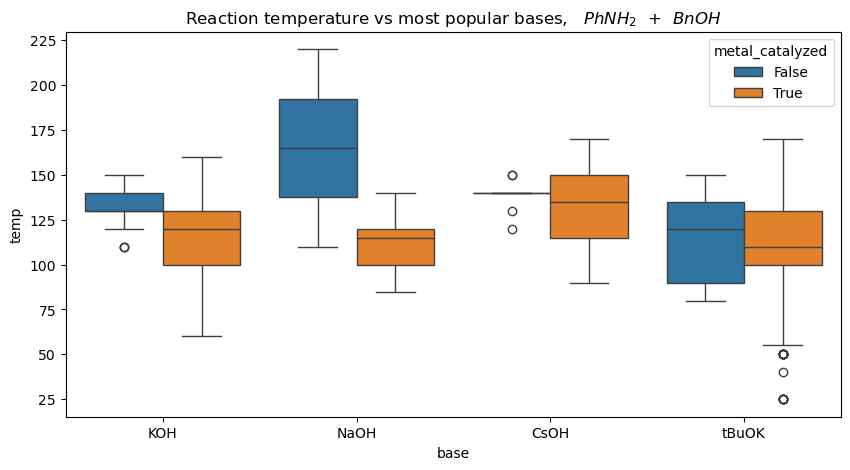

In [82]:
plt.figure(figsize=(10,5))
df_opt_succ['metal_catalyzed'] = ~df_opt_succ['metal'].isna()
sns.boxplot(data=df_opt_succ[df_opt_succ['base'].isin(['tBuOK', 'NaOH', 'CsOH', 'KOH', 'NaOH'])], y="temp", x="base", hue = 'metal_catalyzed')
plt.title(f'Reaction temperature vs most popular bases,  {pf.to_chem('PhNH2')} + {pf.to_chem('BnOH')}', fontsize = 12);
df_opt_succ.drop('metal_catalyzed', axis=1, inplace = True)

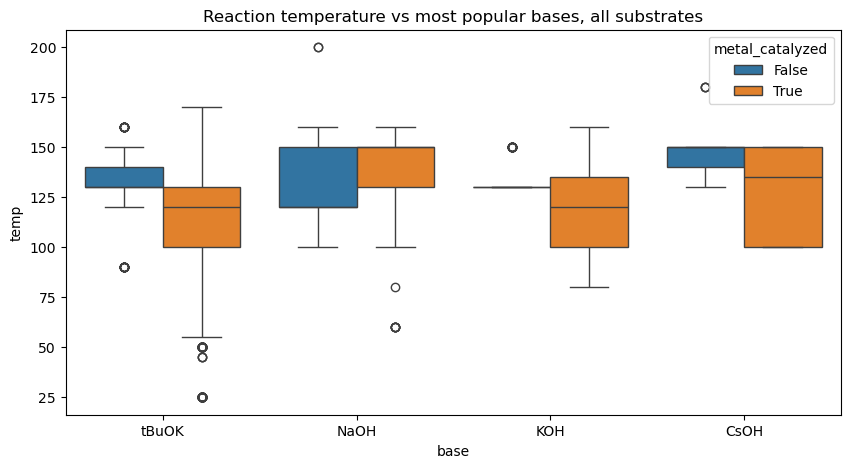

In [84]:
plt.figure(figsize=(10,5))
df_substr_hb_succ['metal_catalyzed'] = ~df_substr_hb_succ['metal'].isna()
sns.boxplot(data=df_substr_hb_succ[df_substr_hb_succ['base'].isin(['tBuOK', 'NaOH', 'CsOH', 'KOH', 'NaOH'])], y="temp", x="base", hue = 'metal_catalyzed')
plt.title(f'Reaction temperature vs most popular bases, all substrates', fontsize = 12);
df_substr_hb_succ.drop('metal_catalyzed', axis=1, inplace = True)

In [91]:
#add temp range
step = 30 #degrees centigrade
def get_temp_range(temp):
    num_range = int(temp/step)
    label = f'[{num_range*step },{(num_range+1)*step })'
    return num_range, label

df_opt['num_temp_range'], df_opt['label_temp_range'] = zip(*df_opt['temp'].apply(get_temp_range))

In [102]:
df_opt['label_temp_range'].value_counts().reset_index().loc[0. ]

,label_temp_range,count
0,"[120,150)",1432
1,"[90,120)",1080
2,"[150,180)",365
3,"[60,90)",340
4,"[30,60)",95
5,"[0,30)",62
6,"[180,210)",55
7,"[210,240)",10


In [111]:
df_90_120 = df_opt[df_opt['label_temp_range'] == '[120,150)']
df_120_150 = df_opt[df_opt['label_temp_range'] == '[90,120)']
df_60_90 = df_opt[df_opt['label_temp_range'] == '[60,90)']


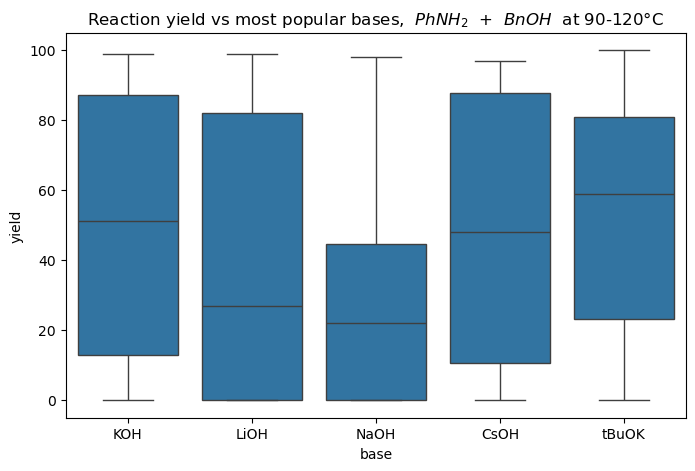

In [109]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_90_120[df_90_120['base'].isin(['tBuOK', 'NaOH', 'CsOH', 'KOH', 'NaOH', 'LiOH'])], y="yield", x="base")
plt.title(f'Reaction yield vs most popular bases, {pf.to_chem('PhNH2')} + {pf.to_chem('BnOH')} at 90-120°C', fontsize = 12);


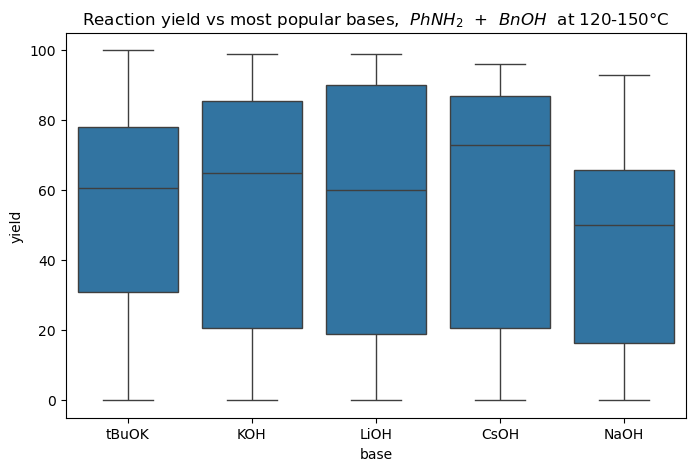

In [110]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_120_150[df_120_150['base'].isin(['tBuOK', 'NaOH', 'CsOH', 'KOH', 'NaOH', 'LiOH'])], y="yield", x="base")
plt.title(f'Reaction yield vs most popular bases, {pf.to_chem('PhNH2')} + {pf.to_chem('BnOH')} at 120-150°C', fontsize = 12);


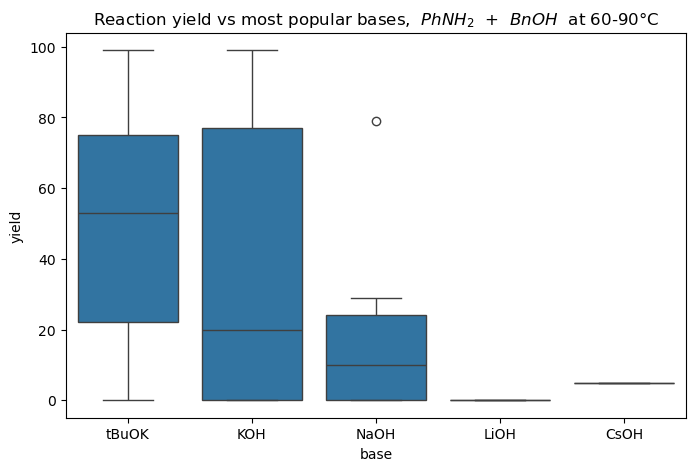

In [112]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_60_90[df_60_90['base'].isin(['tBuOK', 'NaOH', 'CsOH', 'KOH', 'NaOH', 'LiOH'])], y="yield", x="base")
plt.title(f'Reaction yield vs most popular bases, {pf.to_chem('PhNH2')} + {pf.to_chem('BnOH')} at 60-90°C', fontsize = 12);


## Analysys of the optimization data for PhNH<sub>2</sub> + BnOH reaction

In [ ]:
plot_diff_graph(    
    df_opt.loc[(df_opt['success']) & (df_opt['metal']=='Ru')], 
    'base', 
    'num_temp_range',
    filter_val = 0,
    figsize = (12, 8),
    xlabel = 'Temperature range',
    title = 'Relations of bases and temperatures for Ru',
    rename_x_ticks_dict = {idx: f'[{idx*10},{(idx+1)*10})' for idx in range(25)},
    # debug = True
    sort_vertical = True, 
    sort_horizontal = False
)